# Modelos de regresión para datos longitudinales o de panel: remesas y crecimiento económico

## Ejemplo aplicado con datos Banco Mundial para países de América Latina

La idea central es analizar si las **remesas internacionales recibidas como porcentaje del PIB** están asociadas con el **crecimiento del PIB per cápita** en países de América Latina a lo largo del tiempo.

### Pregunta central

> ¿Los países latinoamericanos crecen más en los años en los que reciben más remesas como porcentaje del PIB?

### Enfoque econométrico

Estimaremos con un modelo de panel con efectos fijos por país y por año:

![alt text](image-1.png)

### Fuente de datos

Los datos se descargan desde la API pública del Banco Mundial:

El análisis se realiza para un conjunto de países de América Latina observados entre 2000 y 2024. Los países incluidos son:

- Argentina (`ARG`)
- Bolivia (`BOL`)
- Brasil (`BRA`)
- Chile (`CHL`)
- Colombia (`COL`)
- Costa Rica (`CRI`)
- República Dominicana (`DOM`)
- Ecuador (`ECU`)
- Guatemala (`GTM`)
- Honduras (`HND`)
- México (`MEX`)
- Nicaragua (`NIC`)
- Panamá (`PAN`)
- Perú (`PER`)
- Paraguay (`PRY`)
- El Salvador (`SLV`)
- Uruguay (`URY`)

Los indicadores utilizados son:

- Crecimiento del PIB per cápita anual: `NY.GDP.PCAP.KD.ZG`
- Remesas personales recibidas como % del PIB: `BX.TRF.PWKR.DT.GD.ZS`
- Inflación anual: `FP.CPI.TOTL.ZG`
- Formación bruta de capital como % del PIB: `NE.GDI.TOTL.ZS`
- Comercio como % del PIB: `NE.TRD.GNFS.ZS`

Estas siglas son códigos de indicadores del Banco Mundial. Identificadores técnicos para que la API sepa cual variable corresponde descargar
 



In [16]:
#!pip install pandas requests statsmodels matplotlib

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.3f}".format)


## 1. Selección de países e indicadores

Usaremos un conjunto de países de América Latina. El período elegido será **2000-2024**, aunque la disponibilidad efectiva puede variar según el indicador y el país.


In [17]:
countries = [
    "ARG", "BOL", "BRA", "CHL", "COL", "CRI", "DOM", "ECU",
    "GTM", "HND", "MEX", "NIC", "PAN", "PER", "PRY", "SLV", "URY"
]

indicators = {
    "gdp_pc_growth": "NY.GDP.PCAP.KD.ZG",        # GDP per capita growth, annual %
    "remittances_gdp": "BX.TRF.PWKR.DT.GD.ZS",  # Personal remittances received, % of GDP
    "inflation": "FP.CPI.TOTL.ZG",              # Inflation, consumer prices, annual %
    "investment_gdp": "NE.GDI.TOTL.ZS",         # Gross capital formation, % of GDP
    "trade_gdp": "NE.TRD.GNFS.ZS"               # Trade, % of GDP
}

start_year = 2000
end_year = 2024


## 2. Descarga de datos desde el Banco Mundial

La siguiente función consulta la API del Banco Mundial y devuelve un DataFrame en formato largo.


In [18]:
def fetch_world_bank_indicator(countries, indicator_code, start_year=2000, end_year=2024):
    """Descarga un indicador del Banco Mundial para varios países y años."""
    countries_str = ";".join(countries)
    url = f"https://api.worldbank.org/v2/country/{countries_str}/indicator/{indicator_code}"
    params = {
        "format": "json",
        "per_page": 20000,
        "date": f"{start_year}:{end_year}"
    }

    response = requests.get(url, params=params, timeout=60)
    response.raise_for_status()
    payload = response.json()

    if not isinstance(payload, list) or len(payload) < 2:
        raise ValueError("La API no devolvió datos en el formato esperado.")

    rows = []
    for item in payload[1]:
        rows.append({
            "country": item["country"]["value"],
            "iso3": item.get("countryiso3code"),
            "year": int(item["date"]),
            "value": item["value"]
        })

    return pd.DataFrame(rows)


frames = []
for var_name, indicator_code in indicators.items():
    temp = fetch_world_bank_indicator(countries, indicator_code, start_year, end_year)
    temp = temp.rename(columns={"value": var_name})
    frames.append(temp[["country", "iso3", "year", var_name]])

# Unimos todos los indicadores en un único panel
panel = frames[0]
for temp in frames[1:]:
    panel = panel.merge(temp, on=["country", "iso3", "year"], how="outer")

panel = panel.sort_values(["country", "year"]).reset_index(drop=True)
panel.head()


,country,iso3,year,gdp_pc_growth,remittances_gdp,inflation,investment_gdp,trade_gdp
0,Argentina,ARG,2000,-1.907,0.030,NaN,17.533,22.622
1,Argentina,ARG,2001,-5.453,0.071,NaN,15.626,21.852
2,Argentina,ARG,2002,-11.842,0.211,NaN,10.854,41.753
3,Argentina,ARG,2003,7.718,0.214,NaN,14.147,40.645
4,Argentina,ARG,2004,7.930,0.189,NaN,17.551,40.693


## 3. Exploración inicial del panel

Revisamos el tamaño del panel, la cantidad de países, los años disponibles y la presencia de valores faltantes.


In [19]:
print("Filas:", panel.shape[0])
print("Columnas:", panel.shape[1])
print("Países:", panel["country"].nunique())
print("Años:", panel["year"].min(), "-", panel["year"].max())

panel.isna().mean().sort_values(ascending=False).to_frame("proporción de valores faltantes")


Filas: 425
Columnas: 8
Países: 17
Años: 2000 - 2024


,proporción de valores faltantes
inflation,0.042
remittances_gdp,0.012
country,0.000
iso3,0.000
year,0.000
gdp_pc_growth,0.000
investment_gdp,0.000
trade_gdp,0.000


In [20]:
# Dataset final para estimación: eliminamos observaciones con valores faltantes
df = panel.dropna(subset=[
    "gdp_pc_growth", "remittances_gdp", "inflation", "investment_gdp", "trade_gdp"
]).copy()

print("Observaciones disponibles para el modelo:", df.shape[0])
print("Países incluidos:", df["country"].nunique())
print("Años incluidos:", df["year"].min(), "-", df["year"].max())

df.head()


Observaciones disponibles para el modelo: 402
Países incluidos: 17
Años incluidos: 2000 - 2024


,country,iso3,year,gdp_pc_growth,remittances_gdp,inflation,investment_gdp,trade_gdp
18,Argentina,ARG,2018,-3.416,0.100,34.277,16.614,30.763
19,Argentina,ARG,2019,-2.695,0.125,53.548,14.210,32.631
20,Argentina,ARG,2020,-10.336,0.168,42.015,14.415,30.204
21,Argentina,ARG,2021,10.149,0.186,48.409,18.076,33.079
22,Argentina,ARG,2022,5.797,0.167,72.431,17.386,31.580


## 4. Estadísticas descriptivas

Antes de estimar el modelo, conviene mirar la distribución de las variables principales.


In [21]:
df[[
    "gdp_pc_growth", "remittances_gdp", "inflation", "investment_gdp", "trade_gdp"
]].describe().T


,count,mean,std,min,25%,50%,75%,max
gdp_pc_growth,402.000,2.103,3.767,-18.942,0.788,2.198,3.794,15.070
remittances_gdp,402.000,5.498,6.711,0.000,0.926,2.207,8.080,27.001
inflation,402.000,6.853,14.841,-1.550,2.857,4.450,7.115,219.884
investment_gdp,402.000,21.793,5.381,11.022,18.091,21.193,24.063,43.575
trade_gdp,402.000,66.576,26.650,22.106,48.511,62.943,79.939,164.586


## 5. Gráfico exploratorio

Primero observamos la relación simple entre remesas y crecimiento. Este gráfico no controla por otros factores; sirve solo como exploración inicial.


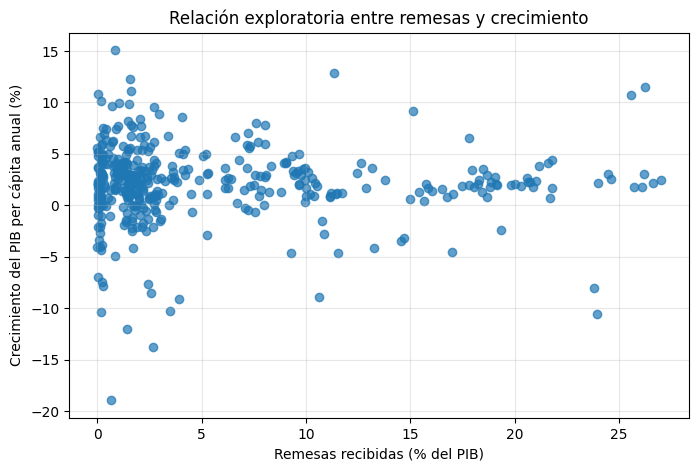

In [22]:
plt.figure(figsize=(8, 5))
plt.scatter(df["remittances_gdp"], df["gdp_pc_growth"], alpha=0.7)
plt.xlabel("Remesas recibidas (% del PIB)")
plt.ylabel("Crecimiento del PIB per cápita anual (%)")
plt.title("Relación exploratoria entre remesas y crecimiento")
plt.grid(True, alpha=0.3)
plt.show()


También podemos observar cómo evolucionan las remesas como porcentaje del PIB para algunos países seleccionados.


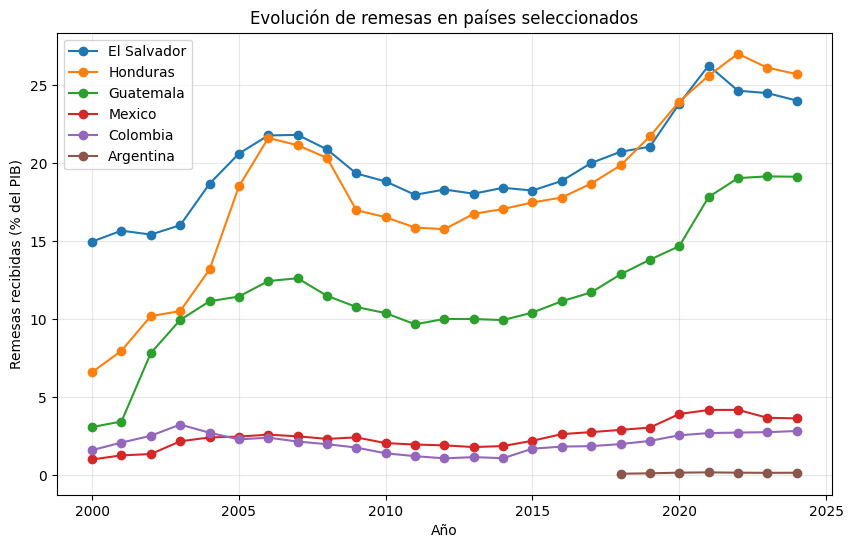

In [31]:
selected_countries = ["El Salvador", "Honduras", "Guatemala", "Mexico", "Colombia", "Argentina"]

plt.figure(figsize=(10, 6))
for country in selected_countries:
    temp = df[df["country"] == country].sort_values("year")
    if not temp.empty:
        plt.plot(temp["year"], temp["remittances_gdp"], marker="o", label=country)

plt.xlabel("Año")
plt.ylabel("Remesas recibidas (% del PIB)")
plt.title("Evolución de remesas en países seleccionados")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 6. Modelo 1: regresión agrupada o pooled OLS

Primero estimamos una regresión simple agrupando todas las observaciones, sin controlar por efectos fijos.

Este modelo es útil como punto de comparación, pero puede estar sesgado porque no controla diferencias estructurales entre países ni shocks comunes de cada año.


In [24]:
pooled_model = smf.ols(
    formula="gdp_pc_growth ~ remittances_gdp + inflation + investment_gdp + trade_gdp",
    data=df
).fit(cov_type="HC1")

print(pooled_model.summary())


                            OLS Regression Results                            
Dep. Variable:          gdp_pc_growth   R-squared:                       0.097
Model:                            OLS   Adj. R-squared:                  0.088
Method:                 Least Squares   F-statistic:                     12.24
Date:                Wed, 13 May 2026   Prob (F-statistic):           2.14e-09
Time:                        21:49:40   Log-Likelihood:                -1082.6
No. Observations:                 402   AIC:                             2175.
Df Residuals:                     397   BIC:                             2195.
Df Model:                           4                                         
Covariance Type:                  HC1                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -2.3435      0.737     

Se puede interpretar de esto segun el R-squared, que las variables incluidas explican el 9,7% de la variación del crecimiento del PIB per cápita, algo normal en modelos macroeconomicos.

## 7. Modelo 2: efectos fijos por país

Ahora agregamos efectos fijos por país usando `C(country)`. Esto permite controlar características propias de cada país que no cambian mucho en el tiempo, como geografía, historia institucional, estructura productiva o cultura económica.


In [25]:
fe_country_model = smf.ols(
    formula="gdp_pc_growth ~ remittances_gdp + inflation + investment_gdp + trade_gdp + C(country)",
    data=df
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df["country"]}
)

print(fe_country_model.summary())


                            OLS Regression Results                            
Dep. Variable:          gdp_pc_growth   R-squared:                       0.233
Model:                            OLS   Adj. R-squared:                  0.192
Method:                 Least Squares   F-statistic:                     18.20
Date:                Wed, 13 May 2026   Prob (F-statistic):           8.40e-06
Time:                        21:49:40   Log-Likelihood:                -1049.8
No. Observations:                 402   AIC:                             2142.
Df Residuals:                     381   BIC:                             2226.
Df Model:                          20                                         
Covariance Type:              cluster                                         
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

c:\Users\Kevin\anaconda3\envs\ldi2_cuda2\lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 20, but rank is 4
  warnings.warn('covariance of constraints does not have full '


## 8. Modelo 3: efectos fijos por país y por año

Este es el modelo principal. Agrega:

- **Efectos fijos por país**: controlan diferencias estructurales entre países.
- **Efectos fijos por año**: controlan shocks comunes a todos los países en un mismo año, como crisis internacionales, pandemia, cambios en tasas de interés globales o variaciones en precios de commodities.

Además, usamos **errores estándar robustos agrupados por país**, una práctica habitual en modelos de panel.


In [26]:
twoway_fe_model = smf.ols(
    formula="gdp_pc_growth ~ remittances_gdp + inflation + investment_gdp + trade_gdp + C(country) + C(year)",
    data=df
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df["country"]}
)

print(twoway_fe_model.summary())


                            OLS Regression Results                            
Dep. Variable:          gdp_pc_growth   R-squared:                       0.706
Model:                            OLS   Adj. R-squared:                  0.670
Method:                 Least Squares   F-statistic:                     33.25
Date:                Wed, 13 May 2026   Prob (F-statistic):           2.83e-09
Time:                        21:49:40   Log-Likelihood:                -857.05
No. Observations:                 402   AIC:                             1804.
Df Residuals:                     357   BIC:                             1984.
Df Model:                          44                                         
Covariance Type:              cluster                                         
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

c:\Users\Kevin\anaconda3\envs\ldi2_cuda2\lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 44, but rank is 16
  warnings.warn('covariance of constraints does not have full '


## 9. Comparación de modelos

Comparamos el modelo agrupado, el modelo con efectos fijos por país y el modelo con efectos fijos por país y año.


In [27]:
model_table = summary_col(
    [pooled_model, fe_country_model, twoway_fe_model],
    model_names=["Pooled OLS", "FE país", "FE país + año"],
    stars=True,
    float_format="%0.3f",
    info_dict={
        "N": lambda x: f"{int(x.nobs)}",
        "R2": lambda x: f"{x.rsquared:.3f}"
    }
)

print(model_table)



                                 Pooled OLS  FE país  FE país + año
-------------------------------------------------------------------
Intercept                        -2.344***  -7.546*** -1.147       
                                 (0.737)    (1.300)   (1.543)      
remittances_gdp                  -0.019     0.068     0.024        
                                 (0.033)    (0.048)   (0.053)      
inflation                        -0.011     -0.016    -0.027*      
                                 (0.009)    (0.012)   (0.015)      
investment_gdp                   0.188***   0.361***  0.174***     
                                 (0.040)    (0.043)   (0.035)      
trade_gdp                        0.008      0.075***  0.027**      
                                 (0.009)    (0.017)   (0.012)      
C(country)[T.Bolivia]                       -1.931*   -1.726       
                                            (1.154)   (1.298)      
C(country)[T.Brazil]                        0.4

## 10. Interpretación del coeficiente de remesas

El coeficiente clave es el de `remittances_gdp`.

La interpretación general es:

> Un aumento de 1 punto porcentual en las remesas recibidas como porcentaje del PIB se asocia con un cambio de β₁ puntos porcentuales en el crecimiento del PIB per cápita, manteniendo constantes las demás variables y controlando por efectos fijos.

Por ejemplo, si el coeficiente estimado fuera `0.30`, se interpretaría así:

> Un aumento de 1 punto porcentual en las remesas como porcentaje del PIB está asociado con un aumento de 0.30 puntos porcentuales en el crecimiento del PIB per cápita, todo lo demás constante.

Importante: esta interpretación habla de **asociación**, no necesariamente de causalidad. Para afirmar causalidad harían falta supuestos más fuertes o estrategias adicionales.


In [28]:
beta = twoway_fe_model.params.get("remittances_gdp", np.nan)
pval = twoway_fe_model.pvalues.get("remittances_gdp", np.nan)

print(f"Coeficiente estimado para remesas_gdp: {beta:.4f}")
print(f"Valor-p: {pval:.4f}")

if pd.notna(beta):
    if pval < 0.05:
        sig_text = "estadísticamente significativo al 5%"
    elif pval < 0.10:
        sig_text = "estadísticamente significativo al 10%"
    else:
        sig_text = "no estadísticamente significativo a niveles convencionales"

    print(
        f"Interpretación: un aumento de 1 punto porcentual en remesas como % del PIB "
        f"se asocia con un cambio de {beta:.3f} puntos porcentuales en el crecimiento "
        f"del PIB per cápita. El resultado es {sig_text}."
    )


Coeficiente estimado para remesas_gdp: 0.0236
Valor-p: 0.6529
Interpretación: un aumento de 1 punto porcentual en remesas como % del PIB se asocia con un cambio de 0.024 puntos porcentuales en el crecimiento del PIB per cápita. El resultado es no estadísticamente significativo a niveles convencionales.


## 11. Robustez simple: excluir inflaciones extremas

En América Latina puede haber episodios de inflación extrema que afecten fuertemente los resultados. Como ejercicio de robustez, estimamos el mismo modelo excluyendo observaciones con inflación anual superior al 100%.

Esto no es obligatorio, pero sirve para mostrar criterio económico y sensibilidad del resultado.


In [29]:
df_robust = df[df["inflation"] <= 100].copy()

twoway_fe_model_robust = smf.ols(
    formula="gdp_pc_growth ~ remittances_gdp + inflation + investment_gdp + trade_gdp + C(country) + C(year)",
    data=df_robust
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_robust["country"]}
)

print("Observaciones modelo original:", df.shape[0])
print("Observaciones modelo robusto:", df_robust.shape[0])
print(twoway_fe_model_robust.summary())


Observaciones modelo original: 402
Observaciones modelo robusto: 400
                            OLS Regression Results                            
Dep. Variable:          gdp_pc_growth   R-squared:                       0.707
Model:                            OLS   Adj. R-squared:                  0.670
Method:                 Least Squares   F-statistic:                     36.42
Date:                Wed, 13 May 2026   Prob (F-statistic):           1.41e-09
Time:                        21:49:40   Log-Likelihood:                -852.02
No. Observations:                 400   AIC:                             1794.
Df Residuals:                     355   BIC:                             1974.
Df Model:                          44                                         
Covariance Type:              cluster                                         
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------

c:\Users\Kevin\anaconda3\envs\ldi2_cuda2\lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 44, but rank is 16
  warnings.warn('covariance of constraints does not have full '


In [30]:
robust_table = summary_col(
    [twoway_fe_model, twoway_fe_model_robust],
    model_names=["FE país + año", "FE país + año, inflación <= 100"],
    stars=True,
    float_format="%0.3f",
    info_dict={
        "N": lambda x: f"{int(x.nobs)}",
        "R2": lambda x: f"{x.rsquared:.3f}"
    }
)

print(robust_table)



                                 FE país + año FE país + año, inflación <= 100
------------------------------------------------------------------------------
Intercept                        -1.147        0.003                          
                                 (1.543)       (2.041)                        
C(country)[T.Bolivia]            -1.726        -2.793                         
                                 (1.298)       (1.726)                        
C(country)[T.Brazil]             -1.017        -1.909                         
                                 (1.182)       (1.555)                        
C(country)[T.Chile]              -2.259*       -3.315*                        
                                 (1.357)       (1.781)                        
C(country)[T.Colombia]           -0.996        -1.966                         
                                 (1.237)       (1.614)                        
C(country)[T.Costa Rica]         -1.178        -2.2

## 12. Conclusiones para la presentación

Una conclusión posible para explicar oralmente:

> En esta aplicación se construyó un panel de países latinoamericanos observados entre 2000 y 2024. La variable dependiente fue el crecimiento del PIB per cápita y la variable explicativa principal fueron las remesas recibidas como porcentaje del PIB. El modelo incorporó controles macroeconómicos como inflación, inversión y comercio, además de efectos fijos por país y por año. Los efectos fijos por país permiten controlar diferencias estructurales no observadas entre países, mientras que los efectos fijos por año controlan shocks comunes como crisis internacionales o la pandemia. El coeficiente de remesas mide si, dentro de un mismo país, los años con mayores remesas se asocian con mayor o menor crecimiento económico. Como en toda regresión observacional, los resultados deben interpretarse como asociaciones y no necesariamente como efectos causales.

### Puntos técnicos para mencionar

- El panel combina dimensión transversal y temporal.
- Los efectos fijos por país controlan heterogeneidad no observada constante en el tiempo.
- Los efectos fijos por año controlan shocks comunes.
- Los errores estándar se agrupan por país para permitir correlación dentro de cada panel.
- La interpretación central se concentra en el coeficiente de remesas.
- La evidencia obtenida es asociativa; no prueba causalidad por sí sola.


## 13. Posibles extensiones

Para una versión más avanzada se podría:

1. Usar rezagos de remesas, por ejemplo `remesas_{t-1}`, porque el efecto sobre crecimiento puede no ser inmediato.
2. Incluir más controles macroeconómicos, como desempleo, tipo de cambio o gasto público.
3. Comparar efectos fijos y efectos aleatorios usando el test de Hausman con la librería `linearmodels`.
4. Usar modelos dinámicos de panel si se incluye el crecimiento pasado como variable explicativa.
5. Explorar causalidad con variables instrumentales, si se encuentra un instrumento válido para remesas.
